In [18]:
# !pip install torch transformers datasets evaluate accelerate scikit-learn matplotlib seaborn
# %pip install evaluate

In [19]:
import evaluate
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)



In [20]:
# 1. Device Setup & Dataset Loading
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Dataset: dair-ai/emotion (sadness=0, joy=1, love=2, anger=3, fear=4, surprise=5)
dataset = load_dataset("dair-ai/emotion")
label_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]

id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in enumerate(label_names)}

print("Dataset splits:", dataset)
print("Labels:", label_names)



Using device: cuda
Dataset splits: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Labels: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [21]:
# 2. Tokenization & Data Collation

MODEL_CHECKPOINT = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def tokenize_batch(examples):
    return tokenizer(examples["text"], truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_batch, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)



In [22]:
# 3. Evaluation Metric Definition
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")["f1"]
    return {"accuracy": acc, "f1": f1}



In [23]:
# 4. Model Initialization

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 10660.32it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [24]:
# 5. Training Arguments & Trainer Setup

training_args = TrainingArguments(
    output_dir="./distilbert_emotion_checkpoints",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    seed=42,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer  # use tokenizer=tokenizer if running an older transformers build
)

In [25]:
# 6. Train the Model

print("Starting DistilBERT fine-tuning...")
trainer.train()



Starting DistilBERT fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.258706,0.201392,0.927000,0.927486
2,0.131046,0.152985,0.939500,0.939142
3,0.108656,0.147239,0.939000,0.938880


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.30it/s]


TrainOutput(global_step=1500, training_loss=0.2981896931330363, metrics={'train_runtime': 132.1061, 'train_samples_per_second': 363.344, 'train_steps_per_second': 11.355, 'total_flos': 647803507542912.0, 'train_loss': 0.2981896931330363, 'epoch': 3.0})


--- Running Predictions on Test Set ---



Classification Report (Test Set):
              precision    recall  f1-score   support

     sadness       0.97      0.96      0.96       581
         joy       0.93      0.96      0.94       695
        love       0.88      0.75      0.81       159
       anger       0.94      0.92      0.93       275
        fear       0.89      0.90      0.89       224
    surprise       0.70      0.77      0.73        66

    accuracy                           0.92      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.92      0.92      0.92      2000



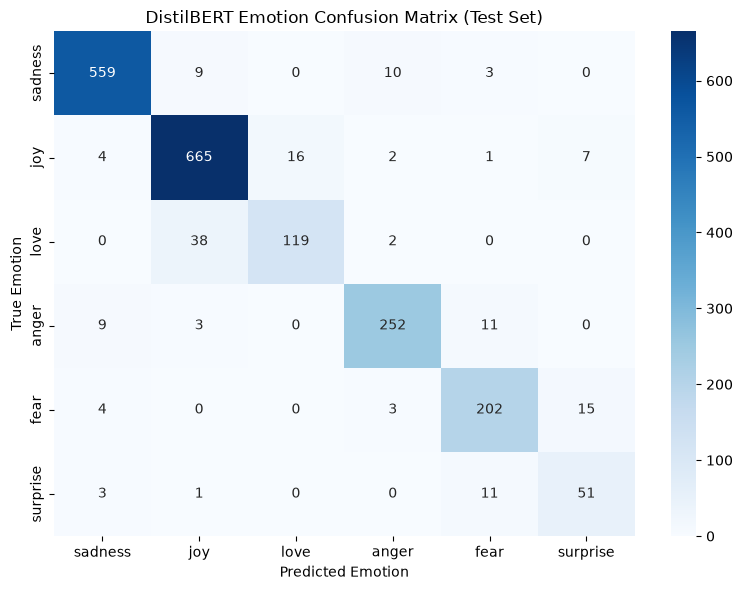

In [26]:
# 7. Test Set Evaluation & Confusion Matrix

print("\n--- Running Predictions on Test Set ---")
test_results = trainer.predict(tokenized_datasets["test"])
test_preds = np.argmax(test_results.predictions, axis=-1)
test_labels = test_results.label_ids

print("\nClassification Report (Test Set):")
print(classification_report(test_labels, test_preds, target_names=label_names))

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.title("DistilBERT Emotion Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("distilbert_emotion_confusion_matrix.png", dpi=300)
plt.show()



In [27]:
# 8. Save Model & Tokenizer for Production Inference

SAVE_PATH = "./distilbert_sentiment_classifier"
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f"Model and tokenizer saved successfully to '{SAVE_PATH}'")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.55it/s]

Model and tokenizer saved successfully to './distilbert_sentiment_classifier'


In [28]:
import torch
import torch.nn.functional as F
from transformers import AutoModelForSequenceClassification, AutoTokenizer

EMOTION_TO_SENTIMENT = {
    "anger": "frustrated",
    "fear": "frustrated",
    "sadness": "frustrated",
    "surprise": "neutral",
    "joy": "satisfied",
    "love": "satisfied"
}

class SentimentInferenceEngine:
    def __init__(self, model_path: str = "./distilbert_sentiment_classifier"):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        self.model = AutoModelForSequenceClassification.from_pretrained(model_path).to(self.device)
        self.model.eval()

    def predict(self, text: str) -> dict:
        inputs = self.tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(self.device)
        with torch.no_grad():
            outputs = self.model(**inputs)
            probs = F.softmax(outputs.logits, dim=-1)[0]
            pred_idx = torch.argmax(probs).item()
            pred_emotion = self.model.config.id2label[pred_idx]
            confidence = probs[pred_idx].item()

        return {
            "text": text,
            "detected_emotion": pred_emotion,
            "detected_sentiment": EMOTION_TO_SENTIMENT.get(pred_emotion, "neutral"),
            "confidence": round(confidence, 4)
        }


In [29]:
# Sanity Check
if __name__ == "__main__":
    engine = SentimentInferenceEngine()

    test_queries = [
        "I have been waiting for my refund for two weeks and no one is replying!",
        "Thanks a lot for resolving my delivery so quickly, amazing support!",
        "Could you check if item #94821 is currently in stock?"
    ]

    for query in test_queries:
        res = engine.predict(query)
        print(f"Text: \"{res['text']}\"")
        print(f"  -> Emotion: [{res['detected_emotion']}] | Tone Bucket: [{res['detected_sentiment']}] (Confidence: {res['confidence']})\n")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 13349.89it/s]


Text: "I have been waiting for my refund for two weeks and no one is replying!"
  -> Emotion: [anger] | Tone Bucket: [frustrated] (Confidence: 0.6496)

Text: "Thanks a lot for resolving my delivery so quickly, amazing support!"
  -> Emotion: [joy] | Tone Bucket: [satisfied] (Confidence: 0.9386)

Text: "Could you check if item #94821 is currently in stock?"
  -> Emotion: [fear] | Tone Bucket: [frustrated] (Confidence: 0.4086)

